# Customer Segmentation Analysis
### Oasis Infobyte — Data Analytics Internship | Task 2

**Objective:** Segment customers based on their purchasing behaviour using
Recency, Frequency, and Monetary (RFM) analysis and K-Means clustering.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Oasis_Task2_Customer_Segmentation_Dataset.csv")

df.head()

,Invoice_No,Invoice_Date,Customer_ID,Product,Quantity,Unit_Price,Country
0,INV500067,2025-01-01 00:00:00,CUST1006,Webcam,3,35.35,India
1,INV500339,2025-01-01 00:00:00,CUST1028,Mechanical Keyboard,6,84.93,Singapore
2,INV500339,2025-01-01 00:00:00,CUST1028,Mini Tripod,5,18.19,Singapore
3,INV500339,2025-01-01 00:00:00,CUST1028,Bluetooth Speaker,6,53.11,Singapore
4,INV500417,2025-01-01 00:00:00,CUST1041,HDMI Cable,1,7.34,United Kingdom


In [3]:
df.shape

(7918, 7)

In [4]:
df.columns

Index(['Invoice_No', 'Invoice_Date', 'Customer_ID', 'Product', 'Quantity',
       'Unit_Price', 'Country'],
      dtype='object')

In [5]:
df.dtypes

,0
Invoice_No,object
Invoice_Date,object
Customer_ID,object
Product,object
Quantity,int64
Unit_Price,float64
Country,object


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7918 entries, 0 to 7917
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Invoice_No    7918 non-null   object 
 1   Invoice_Date  7918 non-null   object 
 2   Customer_ID   7900 non-null   object 
 3   Product       7906 non-null   object 
 4   Quantity      7918 non-null   int64  
 5   Unit_Price    7918 non-null   float64
 6   Country       7918 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 433.1+ KB


In [7]:
df.isnull().sum()

,0
Invoice_No,0
Invoice_Date,0
Customer_ID,18
Product,12
Quantity,0
Unit_Price,0
Country,0


In [8]:
df.duplicated().sum()

np.int64(11)

In [9]:
df.describe()

,Quantity,Unit_Price
count,7918.000000,7918.000000
mean,2.888103,31.295654
std,1.441498,22.998875
min,-6.000000,0.000000
25%,2.000000,12.980000
50%,3.000000,26.750000
75%,4.000000,42.610000
max,6.000000,147.020000


## Initial Data Inspection — Observation

- The dataset contains customer transaction records with invoice, product,
  quantity, price, date, customer, and country information.
- Some Customer_ID and Product values are missing.
- Duplicate transaction records are present.
- Some transactions contain negative quantities, representing returns or
  cancellations.
- Some records contain a zero Unit_Price.
- Invoice_Date needs to be converted from text to datetime before performing
  recency analysis.

## Data Cleaning

In [10]:
clean_df = df.copy()

In [11]:
clean_df = clean_df.drop_duplicates()

clean_df.duplicated().sum()

np.int64(0)

In [12]:
clean_df = clean_df.dropna(subset=['Customer_ID'])

In [13]:
clean_df['Customer_ID'].isnull().sum()

np.int64(0)

In [14]:
clean_df = clean_df[clean_df['Quantity'] > 0]

In [15]:
clean_df = clean_df[clean_df['Unit_Price'] > 0]

In [16]:
clean_df['Invoice_Date'] = pd.to_datetime(clean_df['Invoice_Date'])

In [17]:
clean_df.dtypes

,0
Invoice_No,object
Invoice_Date,datetime64[ns]
Customer_ID,object
Product,object
Quantity,int64
Unit_Price,float64
Country,object


In [18]:
clean_df['Country'] = clean_df['Country'].str.strip().str.title()

In [19]:
clean_df['Country'].value_counts()

,count
Country,
India,4438
Singapore,1163
Uae,1138
United Kingdom,1120


In [20]:
clean_df['Total_Amount'] = (
    clean_df['Quantity'] * clean_df['Unit_Price']
)

In [21]:
clean_df[['Quantity', 'Unit_Price', 'Total_Amount']].head()

,Quantity,Unit_Price,Total_Amount
0,3,35.35,106.05
1,6,84.93,509.58
2,5,18.19,90.95
3,6,53.11,318.66
4,1,7.34,7.34


In [22]:
print("Rows after cleaning:", clean_df.shape[0])
print("Duplicates:", clean_df.duplicated().sum())
print("Missing Customer IDs:", clean_df['Customer_ID'].isnull().sum())
print("Negative quantities:", (clean_df['Quantity'] <= 0).sum())
print("Zero/negative prices:", (clean_df['Unit_Price'] <= 0).sum())

Rows after cleaning: 7859
Duplicates: 0
Missing Customer IDs: 0
Negative quantities: 0
Zero/negative prices: 0


## Data Cleaning — Observation

- Duplicate transaction records were removed.
- Records without Customer_ID were removed because they cannot be assigned to a customer segment.
- Returns and cancelled transactions with non-positive quantities were excluded.
- Transactions with zero or negative prices were removed.
- Invoice_Date was converted to datetime format.
- Country names were standardized for consistency.
- Total_Amount was calculated using Quantity × Unit_Price.
- After cleaning, 7,859 valid transaction records remained.

In [23]:
clean_df['Invoice_Date'].max()

Timestamp('2026-08-30 00:00:00')

In [24]:
analysis_date = clean_df['Invoice_Date'].max() + pd.Timedelta(days=1)

analysis_date

Timestamp('2026-08-31 00:00:00')

In [25]:
rfm = clean_df.groupby('Customer_ID').agg({
    'Invoice_Date': lambda x: (analysis_date - x.max()).days,
    'Invoice_No': 'nunique',
    'Total_Amount': 'sum'
}).reset_index()

rfm.columns = [
    'Customer_ID',
    'Recency',
    'Frequency',
    'Monetary'
]

rfm.head()

,Customer_ID,Recency,Frequency,Monetary
0,CUST1001,12,5,790.03
1,CUST1002,20,24,7110.37
2,CUST1003,26,10,1378.33
3,CUST1004,52,14,1934.23
4,CUST1005,7,7,843.56


In [26]:
rfm[['Recency', 'Frequency', 'Monetary']].describe()

,Recency,Frequency,Monetary
count,400.000000,400.000000,400.000000
mean,61.747500,9.762500,1844.118800
std,81.068452,6.061183,2087.650021
min,1.000000,2.000000,65.520000
25%,13.000000,6.000000,619.610000
50%,33.500000,8.000000,1162.720000
75%,77.000000,13.000000,1865.842500
max,575.000000,28.000000,9798.040000


In [32]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

rfm_features.head()

,Recency,Frequency,Monetary
0,12,5,790.03
1,20,24,7110.37
2,26,10,1378.33
3,52,14,1934.23
4,7,7,843.56


In [35]:
rfm.shape

(400, 4)

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled[:5]

array([[-0.61441658, -0.78672173, -0.50554876],
       [-0.51561096,  2.35190564,  2.52573292],
       [-0.44150674,  0.03923284, -0.22339574],
       [-0.12038847,  0.6999965 ,  0.043218  ],
       [-0.67617009, -0.4563399 , -0.47987538]])

In [37]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

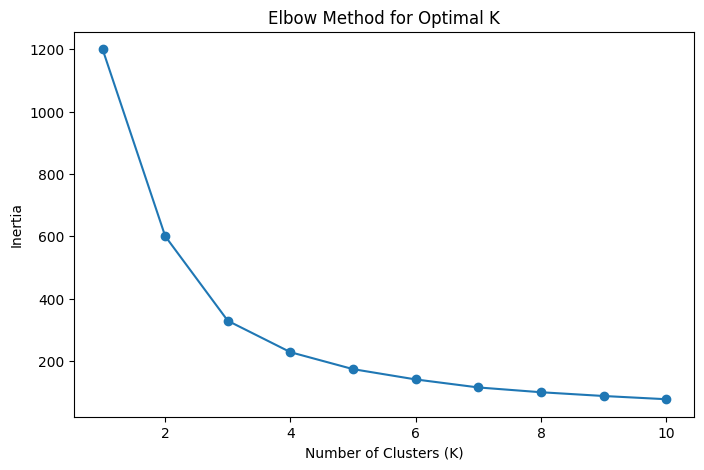

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), inertia, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')

plt.show()

In [39]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Customer_ID,Recency,Frequency,Monetary,Cluster
0,CUST1001,12,5,790.03,0
1,CUST1002,20,24,7110.37,1
2,CUST1003,26,10,1378.33,0
3,CUST1004,52,14,1934.23,0
4,CUST1005,7,7,843.56,0


In [40]:
rfm['Cluster'].value_counts().sort_index()

,count
Cluster,
0,315
1,49
2,36


In [41]:
cluster_profile = rfm.groupby('Cluster')[
    ['Recency', 'Frequency', 'Monetary']
].mean().round(2)

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,45.33,8.43,1222.02
1,13.94,22.67,6872.57
2,270.44,3.86,443.20


## Customer Segment Interpretation

K-Means divided the 400 customers into three distinct customer segments:

- **Cluster 1 — High-Value Customers:** These customers purchase recently and frequently and have the highest average spending. They are the most valuable and engaged customer segment.

- **Cluster 0 — Regular Customers:** These customers show moderate purchase frequency and spending. They represent the largest customer segment and have potential for increased engagement.

- **Cluster 2 — At-Risk / Inactive Customers:** These customers have the highest recency, lowest purchase frequency, and lowest average spending. They have not purchased recently and may require re-engagement strategies.

In [42]:
cluster_names = {
    0: 'Regular Customers',
    1: 'High-Value Customers',
    2: 'At-Risk Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

rfm.head()

,Customer_ID,Recency,Frequency,Monetary,Cluster,Segment
0,CUST1001,12,5,790.03,0,Regular Customers
1,CUST1002,20,24,7110.37,1,High-Value Customers
2,CUST1003,26,10,1378.33,0,Regular Customers
3,CUST1004,52,14,1934.23,0,Regular Customers
4,CUST1005,7,7,843.56,0,Regular Customers


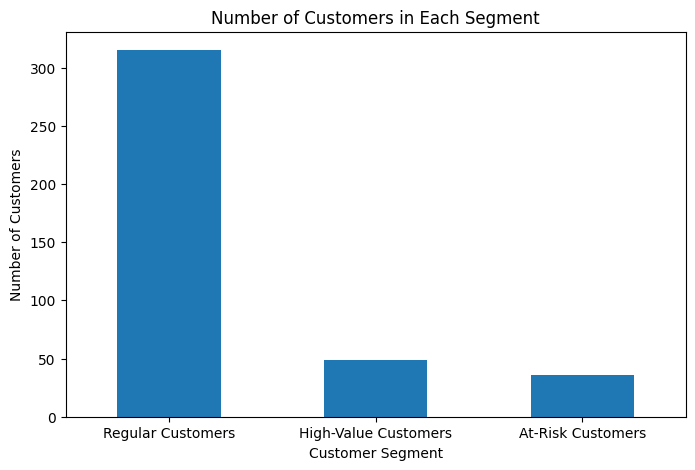

In [43]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(8, 5))
segment_counts.plot(kind='bar')

plt.title('Number of Customers in Each Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)

plt.show()

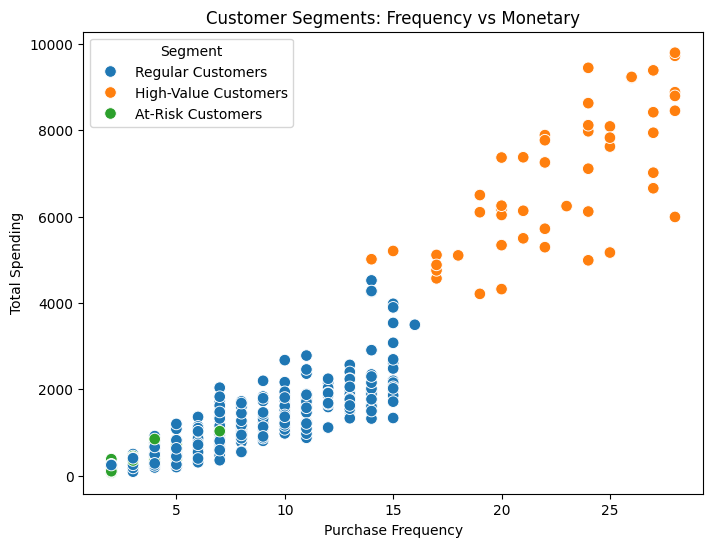

In [44]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    s=70
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Spending')

plt.show()

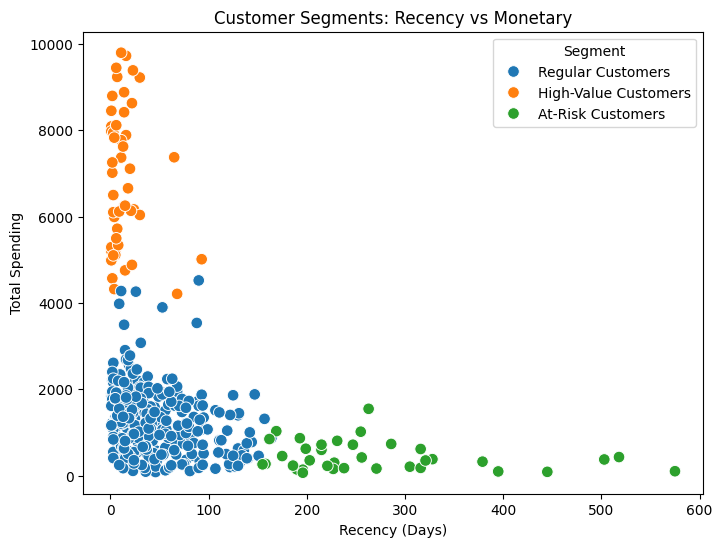

In [45]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Segment',
    s=70
)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Days)')
plt.ylabel('Total Spending')

plt.show()

## Cluster Visualization — Observations

- Regular Customers form the largest segment with 315 customers.
- High-Value Customers have high purchase frequency and substantially higher spending.
- At-Risk Customers show high recency, meaning they have not purchased recently, along with relatively low frequency and spending.
- The clustering results show clear differences in customer purchasing behaviour, allowing different marketing strategies to be applied to each segment.

## Marketing Recommendations

1. **High-Value Customers**
   - Provide loyalty rewards, exclusive offers, and early access to new products.
   - Use personalized recommendations to encourage continued engagement.
   - Focus on retaining these customers because they purchase frequently and contribute the highest spending.

2. **Regular Customers**
   - Use product recommendations, bundles, and limited-time offers to increase purchase frequency and spending.
   - Encourage customers to join loyalty programs.
   - Target this segment for conversion into high-value customers.

3. **At-Risk Customers**
   - Use re-engagement campaigns such as personalized reminders and comeback offers.
   - Provide targeted discounts to encourage another purchase.
   - Investigate possible reasons for their long period of inactivity.

## Conclusion

Customer segmentation was performed using Recency, Frequency, and Monetary (RFM) analysis together with K-Means clustering.

The Elbow Method indicated that three clusters provided a reasonable segmentation of the customer data. The resulting groups were interpreted as High-Value Customers, Regular Customers, and At-Risk Customers.

High-Value Customers purchase recently and frequently and contribute the highest spending. Regular Customers form the largest segment and provide opportunities for increased engagement. At-Risk Customers have not purchased recently and show lower purchase frequency and spending.

These segments can help the business apply different marketing and retention strategies instead of treating all customers in the same way.

In [46]:
rfm.to_csv('Customer_Segmentation_Results.csv', index=False)